In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
# Imports
from IPython.display import display, HTML

def setup_display(width=95, fontsize=16):
    """
    Sets window width and markdown fontsize for Jupyter notebook. Width is % of window.
    """
    display(HTML("<style>.container { width:"+str(width)+"% !important; }</style>"))
    display(HTML("<style>.rendered_html { font-size: "+str(fontsize)+"px; }</style>"))
    return None

def source(fn):
    import inspect
    print(inspect.getsource(fn))
    return None

import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import webbpsf
import astropy.units as u

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

setup_display()

In [5]:
# Prep the SpaceRDI object:
distance = 60.14 # Distance to your target in parsecs

base_dir = 'data_twhya_winnie/'
input_dir = f'{base_dir}padded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

In [6]:
# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI', overwrite=True, verbose=True, pad_data='auto')

In [7]:
# Task 3: Add artifact and apply ref_mask
wdb.load_concat(0)
bad_ind = 3
fake_artifact = np.where(winnie.utils.dist_to_pt([123,248], wdb.nx, wdb.ny) < 2.5, 5.0, 0.0)
wdb.imcube_ref[bad_ind] += fake_artifact

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: RDI (Winnie)
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


In [8]:
# Create reference mask
ref_mask = np.ones((wdb.optzones.shape[0], wdb.imcube_ref.shape[0]), dtype=bool)
ref_mask[:, bad_ind] = False
wdb.set_fixed_rdi_settings(ref_mask=ref_mask)

In [9]:
# TW Hya stellar spectrum from VOTable
import webbpsf_ext
from astropy.table import Table
star_vot = Table.read("fitted_two_component_TWHya.vot")
wave_data = star_vot['wavelength'].value
flux_data = star_vot['sed_flux'].value
wave_units = star_vot['wavelength'].unit
flux_units = star_vot['sed_flux'].unit
print(f"Wave units: {wave_units}, Flux units: {flux_units}")
spec_synphot = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=wave_data,
    flux=flux_data,
    waveunits='micron',   # 
    fluxunits='Jy'      # 'flam' is erg/s/cm^2/A. Adjust to 'Jy', 'photlam', etc. based on your VOTable
)

Wave units: micron, Flux units: Jy


In [10]:
# Prepare PSF convolution grid
# spec_synphot = webbpsf.specFromSpectralType('M0V', catalog='ck04')
try:
    wdb.prepare_convolution(spec_synphot, fov_pixels=201, osamp=2)
except Exception as e:
    print(f"PSF prep failed: {e}")
    wdb.prepare_convolution(None, fov_pixels=201, osamp=2)  # Fallback

Setting up sim to match data_twhya_winnie/padded/jw01179005001_03107_00001_nrca2_calints.fits

MAST OPD query around UTC: 2024-02-14T10:22:56.420
                        MJD: 60354.432597453706

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2024021301-NRCA3_FP1-1.fits
	Date (MJD):	 60353.2554
	Delta time:	 -1.1772 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2024021601-NRCA3_FP1-1.fits
	Date (MJD):	 60355.7958
	Delta time:	 1.3632 days
User requested choosing OPD time closest in time to 2024-02-14T10:22:56.420, which is O2024021301-NRCA3_FP1-1.fits, delta time -1.177 days
Importing and format-converting OPD from /npool/nvme/yuchialin/JWST/stpsf_data/MAST_JWST_WSS_OPDs/O2024021301-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)

Configured simulation instrument for:
    Instrument: NIRCam
    Filter: F200W
    Detector: NRCA2
    Apername: NRCA2_MASK335R
    Det. Pos.: (159,

In [11]:
# Run HPFRDI with ref_mask
wdb.hpfrdi_presets()
hpfrdi_reduc = wdb.run_rdi() 

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e1fb35eb100>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
'ref_mask': <class 'numpy.ndarray'> of shape (1, 241)
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


In [12]:
# Enhanced deconvolution setup
reduc_in = None # for None, run_deconvolution will run a simple HPFRDI reduction and use that for deconvolution
num_iter = 200
return_iters = np.concatenate([np.arange(1,10), np.arange(10,num_iter+1,10)])
excl_mask = winnie.utils.px_size_to_ang_size(
    winnie.utils.dist_to_pt(wdb.c_star, wdb.nx, wdb.ny),
    wdb.pxscale
).value > 7

# Run deconvolution on HPFRDI with artifact mitigation (Combined core)
deconv_reduc = wdb.run_deconvolution(reduc_in, num_iter=num_iter, auto_eps_errtol=0.05, return_iters=return_iters, save_products=True,
show_progress=True, excl_mask_in=excl_mask, init_from_reduc=True)

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7e1fb35eb100>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
'ref_mask': <class 'numpy.ndarray'> of shape (1, 241)
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

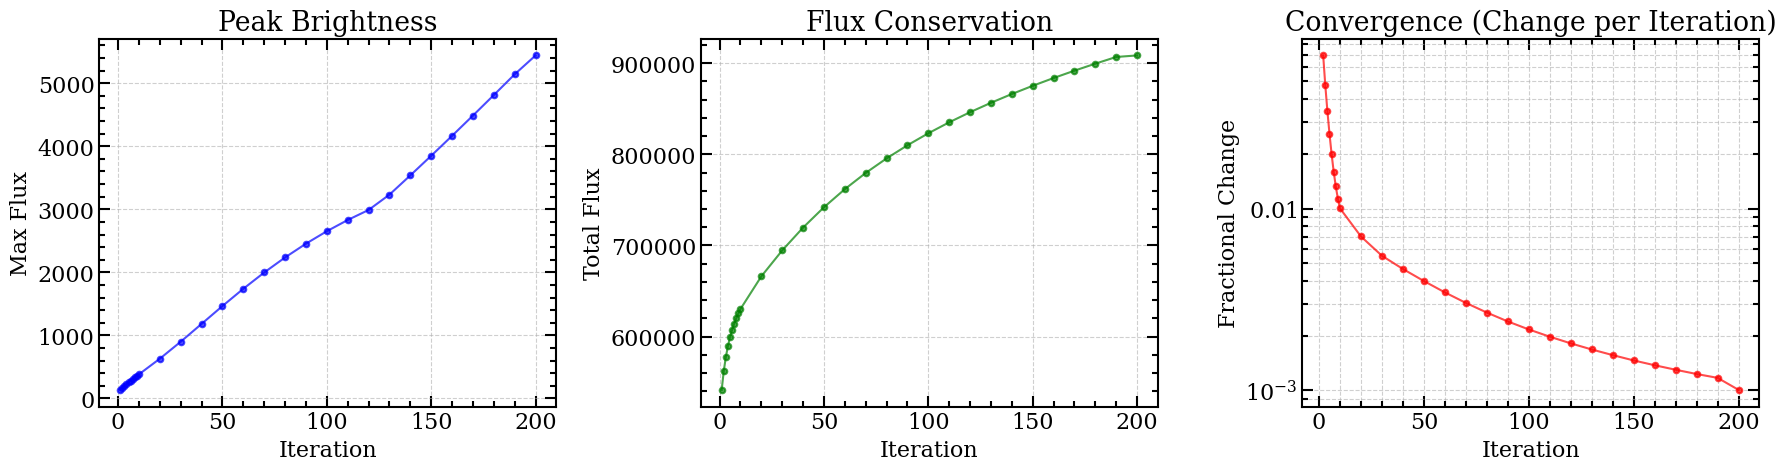

In [13]:
# Extract max flux from each iteration to track convergence
if len(deconv_reduc) > 2:
    # deconv_reduc contains intermediate iterations with shape (n_iters-1, n_rolls, ny, nx)
    # Average over rolling angles (axis 1)
    intermediate_combined = np.mean(deconv_reduc[2], axis=1)
    
    # Combine intermediate images with the final image
    # Ensure final image has same dimensions (1, ny, nx) for concatenation
    final_image = deconv_reduc[0].im[np.newaxis, :, :]
    if intermediate_combined.shape[1:] == final_image.shape[1:]:
        all_iterations = np.concatenate([intermediate_combined[:-1], final_image], axis=0)
    else:
        print(f"Shape mismatch: Intermediates {intermediate_combined.shape} vs Final {final_image.shape}. Using intermediates only.")
        all_iterations = intermediate_combined

    # 1. Max Flux (Peak Brightness)
    max_fluxes = [np.nanmax(im) for im in all_iterations]
    
    # 2. Total Flux (Conservation check)
    total_fluxes = [np.nansum(im) for im in all_iterations]
    
    # 3. Fractional Change (Convergence metric: sum(|current - prev|) / sum(|current|))
    deltas = [np.nan] # First iteration has no previous to compare
    for i in range(1, len(all_iterations)):
        diff = np.nansum(np.abs(all_iterations[i] - all_iterations[i-1]))
        norm = np.nansum(np.abs(all_iterations[i]))
        iters_btw = return_iters[i] - return_iters[i-1]
        deltas.append(diff / norm / iters_btw if norm > 0 else 0)

    # Plotting
    # Adjust return_iters length if we fell back to intermediates only
    iters_to_plot = return_iters if len(max_fluxes) == len(return_iters) else return_iters[:len(max_fluxes)]

    if len(max_fluxes) == len(iters_to_plot):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot Max Flux
        axes[0].plot(iters_to_plot, max_fluxes, 'b-o', markersize=4, alpha=0.7)
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Max Flux')
        axes[0].set_title('Peak Brightness')
        axes[0].grid(True, linestyle='--', alpha=0.6)
        
        # Plot Total Flux
        axes[1].plot(iters_to_plot, total_fluxes, 'g-o', markersize=4, alpha=0.7)
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Total Flux')
        axes[1].set_title('Flux Conservation')
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Plot Convergence (Delta)
        axes[2].plot(iters_to_plot, deltas, 'r-o', markersize=4, alpha=0.7)
        axes[2].set_xlabel('Iteration')
        axes[2].set_ylabel('Fractional Change')
        axes[2].set_title('Convergence (Change per Iteration)')
        axes[2].set_yscale('log')
        axes[2].grid(True, linestyle='--', alpha=0.6, which='both')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Mismatch in lengths: images={len(max_fluxes)}, iters={len(return_iters)}")
else:
    print("Output format does not contain iteration history.")

In [14]:
info_str = "Unknown Filter/Wavelength"
pixel_scale_value = None
units = "arcsec"
try:
    current_concat_key = wdb.concat
    filter_name = wdb.database.obs[current_concat_key]['FILTER'][0]
    wavelength = wdb.database.obs[current_concat_key]['CWAVEL'][0]
    info_str = f"{filter_name} ({wavelength:.2f} µm)"
    pixel_scale_value = wdb.pxscale.to(u.arcsec/u.pixel).value

except NameError:
    print("Warning: 'wdb' object not found. Cannot add scale bar or filter info.")
except AttributeError:
     print("Warning: Could not find 'pxscale' attribute on 'wdb'. Cannot add scale bar.")
except Exception as e:
    print(f"Warning: Could not retrieve info dynamically ({e}). Scale bar or filter info might be missing.")

print(f"Pixel scale found: {pixel_scale_value} {units}/pixel")
print(f"Filter info: {info_str}")

Pixel scale found: 0.03068494 arcsec/pixel
Filter info: F200W (2.00 µm)


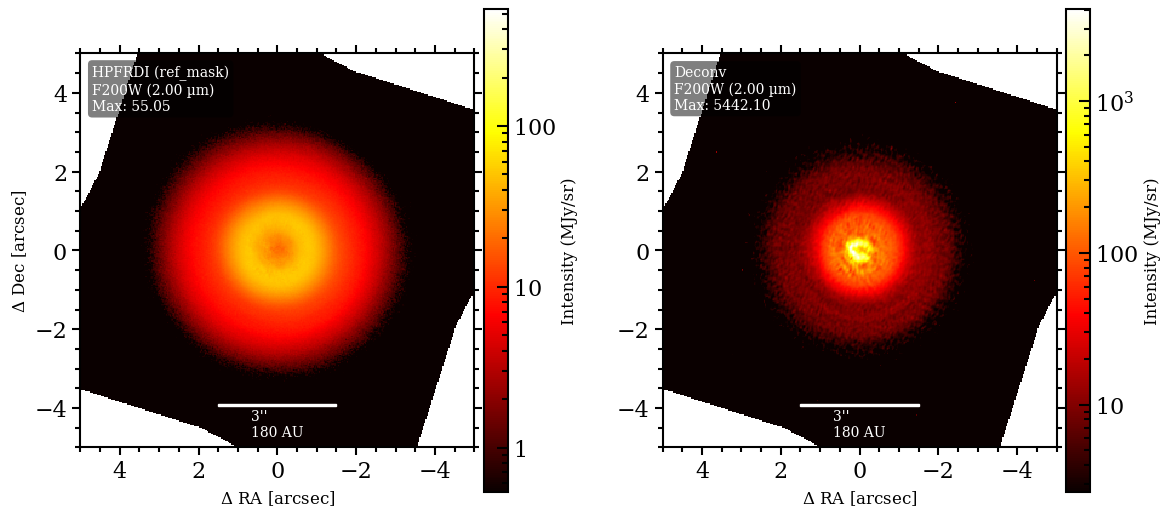

In [15]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar # Import for scale bar
import matplotlib.font_manager as fm # Font properties for scale bar (optional)

images_to_plot = [deconv_reduc[1].im, deconv_reduc[0].im] # Use the deconvolved image and HPFRDI image
labels = ['HPFRDI (ref_mask)', 'Deconv']
# Create figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5)) # Adjusted figsize for colorbars
fontprops = fm.FontProperties(size=10) # Font properties for scale bar label
# Loop through each image/axis to plot individually
for i, ax in enumerate(axes):
    img_data = images_to_plot[i]

    # Calculate color limits for this specific image using the requested formula
    if i == 0:
        clim_low_raw, clim_high_raw = np.array([0.01, 10.0]) * np.nanpercentile(img_data, 99.975)
    else:
        clim_low_raw, clim_high_raw = np.array([0.001, 1.5]) * np.nanpercentile(img_data, 99.975)

    # Create LogNorm object, handling potential non-positive values robustly
    try:
        # Find minimum positive value if needed
        min_positive = np.nanmin(img_data[img_data > 0]) if np.any(img_data > 0) else None
        # Set vmin safely
        vmin_safe = max(clim_low_raw, min_positive) if min_positive is not None and clim_low_raw <= min_positive else clim_low_raw
        if vmin_safe <= 0:
             vmin_safe = 1e-9 # Default tiny positive if calculation failed
             print(f"Warning: Setting vmin to {vmin_safe:.1e} for LogNorm in plot {i} ({labels[i]})")

        # Set vmax safely
        vmax_safe = max(clim_high_raw, vmin_safe * 1.1) # Ensure vmax > vmin
        if vmax_safe <= vmin_safe:
             vmax_safe = vmin_safe * 10
             print(f"Warning: Adjusting vmax for LogNorm in plot {i} ({labels[i]})")

        norm = mpl.colors.LogNorm(vmin=vmin_safe, vmax=vmax_safe, clip=True) # Use clip=True
    except Exception as e:
        print(f"Error creating LogNorm for plot {i}, using linear scale instead: {e}")
        norm = None # Fallback to linear scale

    # --- Plotting ---
    # flip the x-axis extent to match astronomical convention
    flipped_extent = [deconv_reduc[i].extent[1], deconv_reduc[i].extent[0], deconv_reduc[i].extent[2], deconv_reduc[i].extent[3]]
    im = ax.imshow(
        img_data,
        cmap='hot',
        norm=norm, # Apply the LogNorm object (or None for linear)
        extent=flipped_extent, # Use flipped extent from the corresponding reduction object
        origin='lower', # Standard for astronomical images
        interpolation='nearest' # Often preferred over bilinear for data
    )

    # --- Add Colorbar for this specific axis ---
    cbar = fig.colorbar(im, ax=ax, pad=0.02) # Attach colorbar to figure, associated with ax
    cbar_unit = wdb.database.obs[wdb.concat]['BUNIT'][0]
    cbar.set_label('Intensity (%s)' % cbar_unit, fontsize=12)

    # --- Add Text Label ---
    current_max_brightness = np.nanmax(img_data)
    text_label = f"{labels[i]}\n{info_str}\nMax: {current_max_brightness:.2f}"
    ax.text(0.03, 0.97, text_label,
            ha='left', va='top',
            transform=ax.transAxes,
            fontsize=10, color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.5, ec='none'))

    # --- Add Scale Bar ---
    if pixel_scale_value is not None and 'distance' in locals() or 'distance' in globals():
        try:
            scalebar_length_arcsec = 3
            scalebar_length_au = scalebar_length_arcsec * distance # distance needs to be defined
            scalebar_label = f"{scalebar_length_arcsec}''\n{scalebar_length_au:.0f} AU"

            scalebar = AnchoredSizeBar(ax.transData,
                                       scalebar_length_arcsec,
                                       scalebar_label,
                                       'lower center',
                                       pad=0.5, color='white', frameon=False,
                                       size_vertical=scalebar_length_arcsec * 0.02, # Make thickness relative to length
                                       fontproperties=fontprops)
            ax.add_artist(scalebar)
        except Exception as e:
            print(f"Error adding scale bar to plot {i}: {e}")
            ax.text(0.97, 0.03, "Scalebar Error", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=8, color='red')

    else:
        missing_info = []
        if pixel_scale_value is None: missing_info.append("scale")
        if not ('distance' in locals() or 'distance' in globals()): missing_info.append("distance")
        ax.text(0.97, 0.03, f"Scale info missing ({', '.join(missing_info)})", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=8, color='yellow')

    # Set axis limits
    ax.set_xlim(5, -5)
    ax.set_ylim(-5, 5)

    # Set axis labels
    ax.set_xlabel(r'$\Delta$ RA [arcsec]', fontsize=12)
    if i == 0: # Label y-axis only for the first plot
        ax.set_ylabel(r'$\Delta$ Dec [arcsec]', fontsize=12)
    ax.set_aspect('equal', adjustable='box') # Ensure correct aspect ratio
    # Flip ticks outward into the white margin area
    ax.tick_params(axis='both', which='major', direction='out', color='black', labelcolor='black', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', color='black', length=3.5)
    ax.tick_params(top=True, right=True, which='both')

# Adjust layout to prevent overlap and show the plot
plt.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.5) # Added padding
plt.show()

In [16]:
# save the figure into .fits file with header from the first fits file
from astropy.io import fits
winnie_version = 1.1
with fits.open(fitsfiles[0]) as hdul:
    filter_name = hdul[0].header.get('FILTER', 'Unknown')
    fits_path = os.path.join(base_dir, f'{filter_name}.fits')
    # save both deconv_reduc and hpfrdi_reduc to the same fits file
    img_deconv = deconv_reduc[0].im
    img_hpfrdi = deconv_reduc[1].im
    hdu = fits.PrimaryHDU(data = np.stack([img_deconv, img_hpfrdi], axis=-1))
    # Copy header from the first HDU
    hdu.header = hdul[0].header.copy()
    
    # Update header to reflect new data
    hdu.header['NAXIS'] = 3  # 3D data cube
    hdu.header['NAXIS1'] = deconv_reduc[0].im.shape[1]
    hdu.header['NAXIS2'] = deconv_reduc[0].im.shape[0]
    hdu.header['NAXIS3'] = 2  # Two images: deconvolved and HPFRDI
    hdu.header['PIXSCALE'] = wdb.pxscale.to(u.arcsec/u.pixel).value  # Update pixel scale if needed
    hdu.header['PSFSUB'] = 'winnie'
    hdu.header['CREATOR'] = f'winnie-{winnie_version}'
    hdu.header['WDBVERSION'] = winnie_version
    hdu.header['PSFPARAM'] = f'mode=RDI,ref_mask=True,convolution=[False, True], highpass=[True, True], num_iter={num_iter}'
    hdu.header['PSFCENTX'] = deconv_reduc[0].im.shape[1]/2-.5 # These specify the X pixel coordinates (0-indexed from the processing software) of the center of the PSF (the star)
    hdu.header['PSFCENTY'] = deconv_reduc[0].im.shape[0]/2-.5 # These specify the Y pixel coordinates (0-indexed from the processing software) of the center of the PSF (the star)
    hdu.header['CRPIX1'] = deconv_reduc[0].im.shape[1]/2+.5 # Standard FITS World Coordinate System (WCS) keywords. The 1-indexed pixel coordinates of the reference pixel for the WCS transformation.
    hdu.header['CRPIX2'] = deconv_reduc[0].im.shape[0]/2+.5 # Standard FITS World Coordinate System (WCS) keywords. The 1-indexed pixel coordinates of the reference pixel for the WCS transformation.
    hdu.header['HISTORY'] = 'Reduced with winnie using commit 1.1' # History of the reduction
    
    # Print the header for verification
    for card in hdu.header.cards:
        #print(card)
        pass
        
    hdu.writeto(fits_path, overwrite=True)
    print(f"Saved deconvolution and HPFRDI results to {fits_path}")

Saved deconvolution and HPFRDI results to data_twhya_winnie/F200W.fits


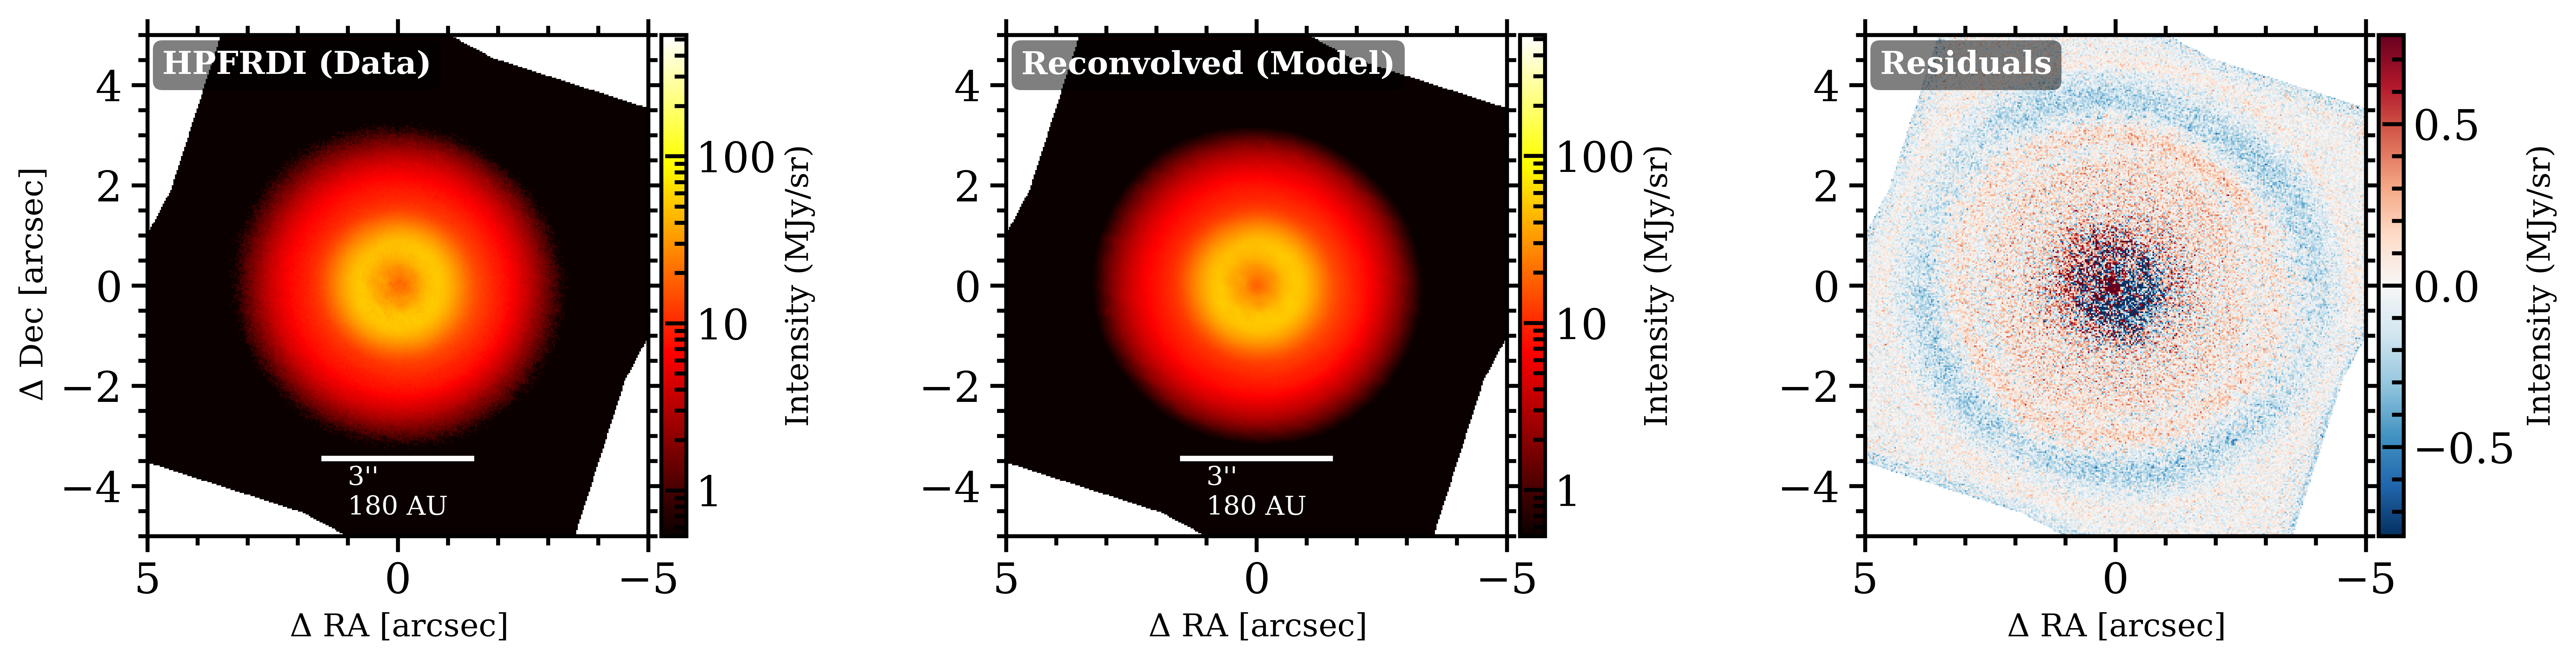

In [17]:
# Reconvolve the deconvolved image through the reduction process

# Set the deconvolved image as the circumstellar model
wdb.set_circumstellar_model(
    raw_model=np.nan_to_num(deconv_reduc[0].im), 
    raw_model_center=deconv_reduc[0].c_star, 
    raw_model_pxscale=deconv_reduc[0].pxscale
)

# Forward model the deconvolved image through the reduction process
reconv_reduc = wdb.derotate_and_combine_circumstellar_model()

# --- Plotting for Data, Model, Residuals ---
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Prepare data
images_to_plot = [hpfrdi_reduc.im, reconv_reduc.im, hpfrdi_reduc.im - reconv_reduc.im]
labels = ['HPFRDI (Data)', 'Reconvolved (Model)', 'Residuals']

# Extent setup
try:
    extent = hpfrdi_reduc.extent
    # flip the x-axis extent to match astronomical convention
    extent = [extent[1], extent[0], extent[2], extent[3]]
except:
    extent = None

# Figure setup
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), dpi=600)
fontprops = fm.FontProperties(size=10)

for i, ax in enumerate(axes):
    img_data = images_to_plot[i]
    
    # Determine Norm and Colormap
    if i == 2: # Residuals - Linear Diverging
        abs_max = np.nanpercentile(np.abs(img_data), 99)
        norm = mpl.colors.Normalize(vmin=-abs_max, vmax=abs_max)
        cmap = 'RdBu_r'
    else: # Data and Model - LogNorm Hot
        # Calculate color limits
        clim_low_raw, clim_high_raw = np.array([0.01, 10.0]) * np.nanpercentile(img_data, 99.975)
        
        try:
            min_positive = np.nanmin(img_data[img_data > 0]) if np.any(img_data > 0) else None
            vmin_safe = max(clim_low_raw, min_positive) if min_positive is not None and clim_low_raw <= min_positive else clim_low_raw
            if vmin_safe <= 0: vmin_safe = 1e-9
            vmax_safe = max(clim_high_raw, vmin_safe * 1.1)
            norm = mpl.colors.LogNorm(vmin=vmin_safe, vmax=vmax_safe, clip=True)
        except Exception as e:
            print(f"Error creating LogNorm for plot {i}: {e}")
            norm = None
        cmap = 'hot'

    # Plot
    im = ax.imshow(
        img_data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin='lower',
        interpolation='nearest'
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    try: cbar_unit = wdb.database.obs[wdb.concat]['BUNIT'][0]
    except: cbar_unit = 'Unknown Unit'
    cbar.set_label('Intensity (%s)' % cbar_unit, fontsize=12)

    # Label
    ax.text(0.03, 0.97, labels[i],
            ha='left', va='top',
            transform=ax.transAxes,
            fontsize=12, color='white', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.5, ec='none'))

    # Scale Bar
    if 'pixel_scale_value' in locals() and pixel_scale_value is not None and ('distance' in locals() or 'distance' in globals()) and i!=2:
        try:
            scalebar_length_arcsec = 3
            scalebar_length_au = scalebar_length_arcsec * distance
            scalebar_label = f"{scalebar_length_arcsec}''\n{scalebar_length_au:.0f} AU"
            scalebar = AnchoredSizeBar(ax.transData, scalebar_length_arcsec, scalebar_label,
                                       'lower center', pad=0.5, color='white', frameon=False,
                                       size_vertical=scalebar_length_arcsec * 0.02, fontproperties=fontprops)
            ax.add_artist(scalebar)
        except Exception as e:
            pass # Scale bar error

    # Axis settings
    ax.set_xlim(5, -5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel(r'$\Delta$ RA [arcsec]', fontsize=12)
    if i == 0: ax.set_ylabel(r'$\Delta$ Dec [arcsec]', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    # Flip ticks outward into the white margin area
    ax.tick_params(axis='both', which='major', direction='out', color='black', labelcolor='black', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', color='black', length=3.5)
    ax.tick_params(top=True, right=True, which='both')

plt.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.5)
plt.show()

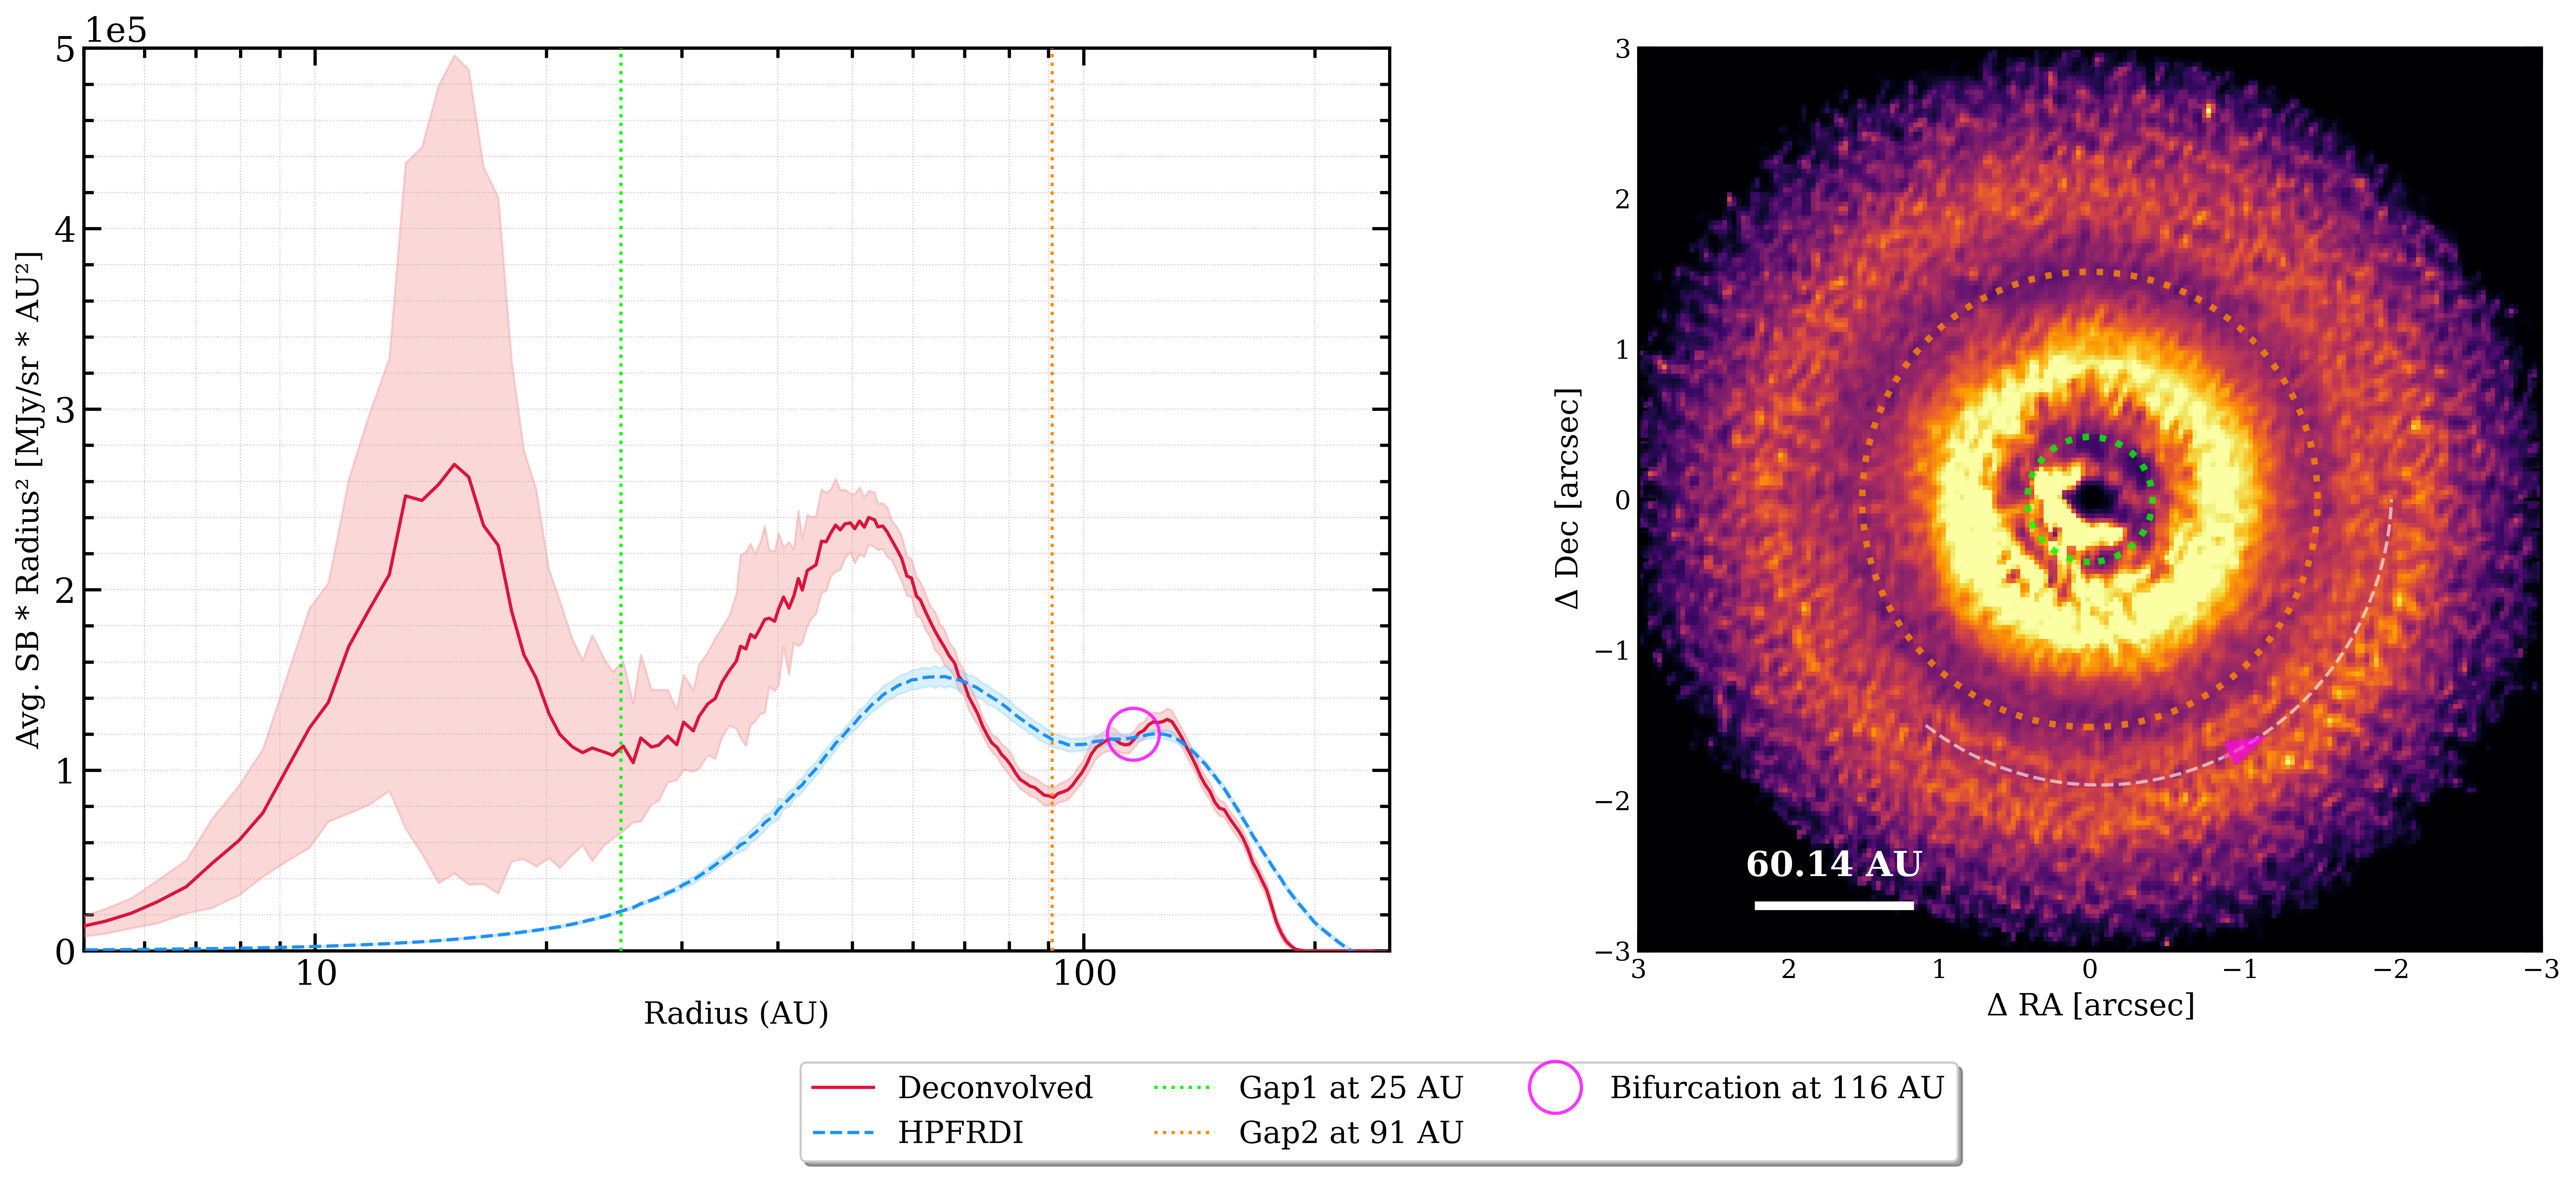

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
from numpy.lib.stride_tricks import sliding_window_view

# ==========================================
# 1. SETUP & SIMPLIFIED PARAMETERS
# ==========================================
pixel_scale = wdb.pxscale.to(u.arcsec/u.pixel).value 
dist = 60.14 
beam_size_pix = 46.528953706984169 

# --- User Choices ---
OUTLIER_CLIP = 0.06
X_AXIS_SCALE = 'log'

img_deconv = deconv_reduc[0].im
img_hpfrdi = deconv_reduc[1].im

labels = ['Deconvolved', 'HPFRDI']
colors = ['crimson', 'dodgerblue']
fill_colors = ['lightcoral', 'lightskyblue']

# Optimized Overlay Colors
color_gap1 = 'lime'
color_gap2 = 'darkorange'
color_bifurcation = 'magenta' 

ny, nx = img_deconv.shape
center_y, center_x = ny // 2, nx // 2
max_radius_px = min(ny, nx) // 2

# ==========================================
# 2. FAST 1D SLIDING WINDOW RADIAL PROFILE
# ==========================================
def calculate_radial_profile_fast(image_data, center_yx, max_radius_px, beam_size_pix, clip_frac=0.0, thin=True):
    ny, nx = image_data.shape
    cy, cx = center_yx
    y, x = np.ogrid[:ny, :nx]
    
    # 2a. Calculate physical radius of every pixel
    r_grid = np.sqrt((x - cx)**2 + (y - cy)**2)

    # 2b. Flatten and filter out invalid (NaN/Inf) pixels
    valid_mask = np.isfinite(image_data)
    r_flat = r_grid[valid_mask]
    vals_flat = image_data[valid_mask]

    # 2c. Sort arrays by radius to allow fast binary search windowing
    sort_idx = np.argsort(r_flat)
    sorted_r = r_flat[sort_idx]
    sorted_vals = vals_flat[sort_idx]
    
    # 2d. Create sliding windows of size beam_size_pix
    window_shape = int(beam_size_pix)
    if thin:
        selected_idx = np.cumsum(np.arange(1, window_shape+1))
        val_windows = sliding_window_view(sorted_vals[:window_shape*(window_shape+3)//2], window_shape=window_shape)
        radii_windows = sliding_window_view(sorted_r[:window_shape*(window_shape+3)//2], window_shape=window_shape)
        val_windows = val_windows[selected_idx]
        radii_windows = radii_windows[selected_idx]
    else:
        val_windows = sliding_window_view(sorted_vals, window_shape=window_shape)
        radii_windows = sliding_window_view(sorted_r, window_shape=window_shape)
    
    # 2e. Filter out the outlier pixels in each window if clip_frac > 0
    if clip_frac > 0:
        # SPEEDUP: Use np.percentile instead of np.nanpercentile since no NaNs exist here yet
        low, high = np.percentile(val_windows, [clip_frac/2 * 100, (1 - clip_frac/2) * 100], axis=1)
        mask = (val_windows >= low[:, None]) & (val_windows <= high[:, None])
        val_windows = np.where(mask, val_windows, np.nan)  # Replace outliers
        radii_windows = np.where(mask, radii_windows, np.nan)  # Keep radius aligned
        
    # 2f. Calculate effective radius, mean and std for each window
    eff_radii = np.nanmean(radii_windows, axis=1)
    means = np.nanmean(val_windows, axis=1)
    
    # Calculate valid pixel count (summing the boolean mask is faster if we clipped)
    if clip_frac > 0:
        pixel_count = np.sum(mask, axis=1)
    else:
        pixel_count = np.full(val_windows.shape[0], window_shape)
        
    stds = np.nanstd(val_windows, axis=1) / np.sqrt(pixel_count / beam_size_pix)
    
    # 2g. Calculate the outer part of the profile if thinning is enabled
    if thin:
        sorted_r = sorted_r[window_shape*(window_shape+3)//2:]
        sorted_vals = sorted_vals[window_shape*(window_shape+3)//2:]
        # divide the remaining sorted arrays into logarithmically spaced bins for the outer profile
        num_bins = 200
        log_bins = np.logspace(np.log10(np.min(sorted_r)), np.log10(max_radius_px), num_bins + 1)
        bin_indices = np.digitize(sorted_r, log_bins) - 1
        means_outer, stds_outer, eff_radii_outer = [], [], []
        for i in range(num_bins):
            bin_mask = (bin_indices == i)
            if np.any(bin_mask):
                vals_in_bin = sorted_vals[bin_mask]
                r_in_bin = sorted_r[bin_mask]
                if clip_frac > 0 and len(vals_in_bin) > 2:
                    low, high = np.percentile(vals_in_bin, [clip_frac/2 * 100, (1 - clip_frac/2) * 100])
                    valid_mask = (vals_in_bin >= low) & (vals_in_bin <= high)
                    
                    vals_in_bin = vals_in_bin[valid_mask]
                    r_in_bin = r_in_bin[valid_mask]
                
                if len(vals_in_bin) > 0:
                    means_outer.append(np.mean(vals_in_bin))
                    stds_outer.append(np.std(vals_in_bin) / np.sqrt(len(vals_in_bin)/beam_size_pix) if len(vals_in_bin) > 1 else 0.0)
                    eff_radii_outer.append(np.mean(r_in_bin))
        # Append the outer profile to the main profile
        eff_radii = np.concatenate([eff_radii, np.array(eff_radii_outer)])
        means = np.concatenate([means, np.array(means_outer)])
        stds = np.concatenate([stds, np.array(stds_outer)])
    return eff_radii, means, stds

# --- Calculate Profiles & Conversions ---
radii_px_list, profiles_mean, profiles_std = [], [], []

for img in [img_deconv, img_hpfrdi]:
    r, mean, std = calculate_radial_profile_fast(
        img, (center_y, center_x), max_radius_px, beam_size_pix, clip_frac=OUTLIER_CLIP
    )
    radii_px_list.append(r)
    profiles_mean.append(mean)
    profiles_std.append(std)

# Direct Unit Conversion
pixel_scale_au = pixel_scale * dist
radii_plot = radii_px_list[0] * pixel_scale_au
x_label = 'Radius (AU)'
y_label = 'Avg. SB * Radius² [MJy/sr * AU²]'

# ==========================================
# 3. CREATE MASTER FIGURE & RADIAL PLOT
# ==========================================
fig, (ax_radial, ax_image) = plt.subplots(1, 2, figsize=(18, 7), dpi=600)

for i in range(len(profiles_mean)):
    valid = np.isfinite(profiles_mean[i]) & (radii_plot > 0)
    if not np.any(valid): continue

    r_valid = radii_plot[valid]
    sb_r2 = profiles_mean[i][valid] * r_valid**2
    err_sb_r2 = profiles_std[i][valid] * r_valid**2

    ax_radial.plot(r_valid, sb_r2, label=labels[i], color=colors[i], 
                   linestyle='-' if i==0 else '--', linewidth=1.5, zorder=10)
    ax_radial.fill_between(r_valid, sb_r2 - err_sb_r2, sb_r2 + err_sb_r2,
                           color=fill_colors[i], alpha=0.3, label='_nolegend_', zorder=5)

# Style Radial Plot
ax_radial.set_xlabel(x_label, fontsize=14)
ax_radial.set_ylabel(y_label, fontsize=14)
ax_radial.set_xscale(X_AXIS_SCALE)
ax_radial.set_xlim(left=5, right=250 if X_AXIS_SCALE == 'log' else np.nanmax(radii_plot)*1.05)
ax_radial.set_ylim(bottom=0, top = 5e5)
ax_radial.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_radial.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.7)

# Overlay Radial Lines
ax_radial.axvline(x=25, color=color_gap1, linestyle=':', linewidth=1.5, label='Gap1 at 25 AU', zorder=12)
ax_radial.axvline(x=91, color=color_gap2, linestyle=':', linewidth=1.5, label='Gap2 at 91 AU', zorder=12)
ax_radial.plot(116, 1.2e5, 'o', color=color_bifurcation, markersize=24, 
               label='Bifurcation at 116 AU', zorder=15, fillstyle='none', alpha=0.8)

# Info Box
textstr = f"Filter: F200W\nPixel Scale: {pixel_scale:.3f} as/pix"
#ax_radial.text(0.97, 0.7, textstr, transform=ax_radial.transAxes, fontsize=14, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ==========================================
# 4. PLOT 2D IMAGE
# ==========================================
extent_arcsec = 6.0 
half_extent = extent_arcsec / 2
extent = [half_extent, -half_extent, -half_extent, half_extent]

# Crop and process image
half_ext_px = int((extent_arcsec / pixel_scale) / 2)
y_slice = slice(max(0, center_y - half_ext_px), min(ny, center_y + half_ext_px))
x_slice = slice(max(0, center_x - half_ext_px), min(nx, center_x + half_ext_px))

cropped_image = img_deconv[y_slice, x_slice]
y_grid, x_grid = np.ogrid[-half_ext_px:half_ext_px,-half_ext_px:half_ext_px]
distances_arcsec = np.sqrt(x_grid**2 + y_grid**2) * pixel_scale

scaled_image = cropped_image * distances_arcsec**2
normalized_image = scaled_image / np.nanpercentile(scaled_image, 97)

ax_image.imshow(normalized_image, origin='lower', cmap='inferno', vmax=1.0, vmin=0.0, extent=extent)

# Scale Bar
bar_x, bar_y = half_extent - 0.8, -half_extent + 0.3
ax_image.plot([bar_x - 1.0, bar_x], [bar_y, bar_y], 'white', linewidth=4)
ax_image.text(bar_x - 0.5, bar_y + 0.15, f'{1.0 * dist} AU', color='white', ha='center', va='bottom', fontweight='bold')

# --- Add 2D Rings ---
r_gap1_arcsec, r_gap2_arcsec = 25/dist, 91/dist

ax_image.add_patch(patches.Circle((0, 0), r_gap1_arcsec, color=color_gap1, fill=False, linestyle=':', linewidth=3, alpha=0.8))
ax_image.add_patch(patches.Circle((0, 0), r_gap2_arcsec, color=color_gap2, fill=False, linestyle=':', linewidth=3, alpha=0.8))

# --- Add Unified Log Spiral ---
theta = np.linspace(-0.7 * np.pi, 0, 100)
r_spiral = np.exp(np.tan(np.radians(2)) * theta)
r_spiral *= 116/dist/np.mean(r_spiral)  
x_spiral, y_spiral = r_spiral * np.cos(theta), r_spiral * np.sin(theta)

ax_image.plot(-x_spiral, y_spiral, color="white", linestyle='--', linewidth=1.5, alpha=0.6)
ax_image.arrow(-x_spiral[50], y_spiral[50], 
               -(x_spiral[51]-x_spiral[50]), (y_spiral[51]-y_spiral[50]),
               head_width=0.15, head_length=0.25, fc=color_bifurcation, ec=color_bifurcation, alpha=0.6, zorder=20)

ax_image.set_xlabel(r'$\Delta$ RA [arcsec]', fontsize=14)
ax_image.set_ylabel(r'$\Delta$ Dec [arcsec]', fontsize=14)
ax_image.tick_params(labelsize=12)

# ==========================================
# 5. FINALIZE & SAVE
# ==========================================
plt.tight_layout()

# Shared Legend
handles_rad, labels_rad = ax_radial.get_legend_handles_labels()
handles_img, labels_img = ax_image.get_legend_handles_labels()

# Deduplicate legend items automatically
by_label = dict(zip(labels_rad + labels_img, handles_rad + handles_img))

fig.legend(by_label.values(), by_label.keys(), 
           loc='lower center', bbox_to_anchor=(0.5, -0.1), 
           ncol=3, frameon=True, shadow=True, fontsize=14)

plt.savefig('f200w_radial.png', dpi=600, bbox_inches='tight')
plt.show()